<table align="left"  width="100%"> <tr>
        <td  style="background-color:#ffffff;">
            <a href="https://qworld.net" target="_blank"><img src="../images/qworld.jpg" width="35%" align="left"> </a></td>
        <td style="background-color:#ffffff;vertical-align:bottom;text-align:right;">
            prepared by Maksim Dimitrijev (<a href="https://qworld.net/index.php/qlatvia/" target="_blank">QLatvia</a>)
        </td>        
</tr></table>

<table width="100%"><tr><td style="color:#bbbbbb;background-color:#ffffff;font-size:11px;font-style:italic;text-align:right;">This cell contains some macros. If there is a problem with displaying mathematical formulas, please run this cell to load these macros. </td></tr></table>

$$
\newcommand{\bra}[1]{\langle #1|}
\newcommand{\ket}[1]{|#1\rangle}
\newcommand{\braket}[2]{\langle #1|#2\rangle}
\newcommand{\dot}[2]{ #1 \cdot #2}
\newcommand{\biginner}[2]{\left\langle #1,#2\right\rangle}
\newcommand{\mymatrix}[2]{\left( \begin{array}{#1} #2\end{array} \right)}
\newcommand{\myvector}[1]{\mymatrix{c}{#1}}
\newcommand{\myrvector}[1]{\mymatrix{r}{#1}}
\newcommand{\mypar}[1]{\left( #1 \right)}
\newcommand{\mybigpar}[1]{ \Big( #1 \Big)}
\newcommand{\sqrttwo}{\frac{1}{\sqrt{2}}}
\newcommand{\dsqrttwo}{\dfrac{1}{\sqrt{2}}}
\newcommand{\onehalf}{\frac{1}{2}}
\newcommand{\donehalf}{\dfrac{1}{2}}
\newcommand{\hadamard}{ \mymatrix{rr}{ \sqrttwo & \sqrttwo \\ \sqrttwo & -\sqrttwo }}
\newcommand{\vzero}{\myvector{1\\0}}
\newcommand{\vone}{\myvector{0\\1}}
\newcommand{\stateplus}{\myvector{ \sqrttwo \\  \sqrttwo } }
\newcommand{\stateminus}{ \myrvector{ \sqrttwo \\ -\sqrttwo } }
\newcommand{\myarray}[2]{ \begin{array}{#1}#2\end{array}}
\newcommand{\X}{ \mymatrix{cc}{0 & 1 \\ 1 & 0}  }
\newcommand{\Z}{ \mymatrix{rr}{1 & 0 \\ 0 & -1}  }
\newcommand{\Htwo}{ \mymatrix{rrrr}{ \frac{1}{2} & \frac{1}{2} & \frac{1}{2} & \frac{1}{2} \\ \frac{1}{2} & -\frac{1}{2} & \frac{1}{2} & -\frac{1}{2} \\ \frac{1}{2} & \frac{1}{2} & -\frac{1}{2} & -\frac{1}{2} \\ \frac{1}{2} & -\frac{1}{2} & -\frac{1}{2} & \frac{1}{2} } }
\newcommand{\CNOT}{ \mymatrix{cccc}{1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & 0 & 1 \\ 0 & 0 & 1 & 0} }
\newcommand{\norm}[1]{ \left\lVert #1 \right\rVert }
\newcommand{\pstate}[1]{ \lceil \mspace{-1mu} #1 \mspace{-1.5mu} \rfloor }
\newcommand{\Y}{ \mymatrix{rr}{0 & -i \\ i & 0} }
\newcommand{\S}{ \mymatrix{rr}{1 & 0 \\ 0 & i} }
\newcommand{\T}{ \mymatrix{rr}{1 & 0 \\ 0 & e^{i \frac{\pi}{4}}} }
\newcommand{\Sdg}{ \mymatrix{rr}{1 & 0 \\ 0 & -i} }
\newcommand{\Tdg}{ \mymatrix{rr}{1 & 0 \\ 0 & e^{-i \frac{\pi}{4}}} }
\newcommand{\qgate}[1]{ \mathop{\textit{#1} } }
$$

<h1> <font color="blue"> Solutions for </font> Quantum gates with complex numbers </h1>

<a id="task1"></a>
<h3> Task 1 </h3>

Remember that $\qgate{X}$-gate flips the value of a qubit.

Design a quantum circuit with a single qubit. Set the value of qubit to $ \ket{1} $ by using x-gate. After that apply $\qgate{Y}$-gate and check the outcome on a statevector_simulator.

<h3> Solution </h3>

State after X-Y: [0.-1.j 0.+0.j]
State  Amplitude  Probability
  |0>   0.0-1.0j          1.0
  |1>   0.0+0.0j          0.0


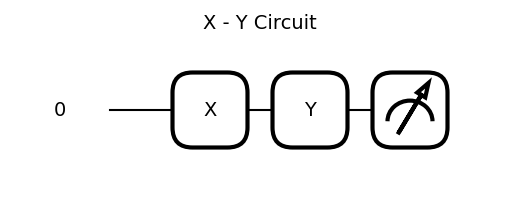

In [11]:
import pennylane as qp
import pandas as pd
import matplotlib.pyplot as plt

dev = qp.device("default.qubit", wires=1)

@qp.qnode(dev)
def circuit():
    # apply x-gate
    qp.PauliX(wires=0)

    # apply y-gate
    qp.PauliY(wires=0)

    return qp.state()

current_quantum_state = circuit()
print('State after X-Y:', current_quantum_state)

df = pd.DataFrame({
    'State': ['|0>', '|1>'],
    'Amplitude': [current_quantum_state[0], current_quantum_state[1]],
    'Probability': [abs(current_quantum_state[0])**2, abs(current_quantum_state[1])**2]
})
print(df.to_string(index=False))

fig, ax = qp.drawer.draw_mpl(circuit)()
fig.suptitle('X - Y Circuit', fontsize=14)
plt.show()

<a id="task2"></a>
<h3> Task 2 </h3>

Find the relationship between the following operators:
<ul>
    <li>$\qgate{S}$ and $\qgate{T}$;</li>
    <li>$\qgate{Z}$ and $\qgate{T}$.</li>
</ul>

<h3> Solution </h3>

$\qgate{S} = \S = \mymatrix{cc}{1 & 0 \\ 0 & e^{i \frac{\pi}{4}} \cdot e^{i \frac{\pi}{4}}} = \T \T$ => $\qgate{S} = T^2$.

$\qgate{Z} = \Z = \mymatrix{cc}{1 & 0 \\ 0 & i \cdot i} = \S \S$ => $\qgate{Z} = S^2$ => $\qgate{Z} = T^4$.

<a id="task3"></a>
<h3> Task 3 </h3>

For each one of the discussed 4 phase gates construct the following circuit:

<ul>
    <li>Create a circuit with one qubit,</li>
    <li>apply Hadamard operator,</li>
    <li>apply the corresponding phase operator,</li>
    <li>make a measurement.</li>
</ul>

What is the measurement outcome in each case?

<h3> Solution </h3>

H-S circuit results:
State  Count  Probability
    0   5004       0.5004
    1   4996       0.4996
0: ──H──S─┤  Counts


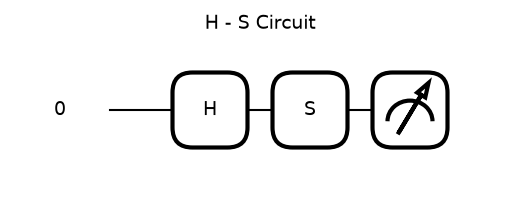

In [7]:
import pennylane as qp
import pandas as pd
import matplotlib.pyplot as plt

dev = qp.device("default.qubit", wires=1)

@qp.set_shots(shots=10000)
@qp.qnode(dev)
def circuit_s():
    qp.Hadamard(wires=0)
    # s-gate
    qp.S(wires=0)
    return qp.counts(wires=[0])

counts = circuit_s()

df = pd.DataFrame(list(counts.items()), columns=['State', 'Count'])
df['Probability'] = df['Count'] / df['Count'].sum()
print('H-S circuit results:')
print(df.to_string(index=False))

print(qp.draw(circuit_s)())

fig, ax = qp.drawer.draw_mpl(circuit_s)()
fig.suptitle('H - S Circuit', fontsize=14)
plt.show()

H-T circuit results:
State  Count  Probability
    0   5089       0.5089
    1   4911       0.4911
0: ──H──T─┤  Counts


C:\Users\user\anaconda3\Lib\site-packages\pennylane\devices\device_api.py:207: PennyLaneDeprecationWarning: Setting shots on device is deprecated. Please use the `set_shots` transform on the respective QNode instead.
  warnings.warn(


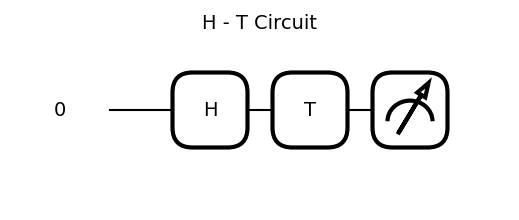

In [13]:
import pennylane as qp
import pandas as pd
import matplotlib.pyplot as plt

dev = qp.device("default.qubit", wires=1)

@qp.set_shots(shots=10000)
@qp.qnode(dev)
def circuit_t():
    qp.Hadamard(wires=0)
    # t-gate
    qp.T(wires=0)
    return qp.counts(wires=[0])

counts = circuit_t()

df = pd.DataFrame(list(counts.items()), columns=['State', 'Count'])
df['Probability'] = df['Count'] / df['Count'].sum()
print('H-T circuit results:')
print(df.to_string(index=False))

print(qp.draw(circuit_t)())

fig, ax = qp.drawer.draw_mpl(circuit_t)()
fig.suptitle('H - T Circuit', fontsize=14)
plt.show()

C:\Users\user\anaconda3\Lib\site-packages\pennylane\devices\device_api.py:207: PennyLaneDeprecationWarning: Setting shots on device is deprecated. Please use the `set_shots` transform on the respective QNode instead.
  warnings.warn(


H-Sdg circuit results:
State  Count  Probability
    0   5077       0.5077
    1   4923       0.4923
0: ──H──S†─┤  Counts


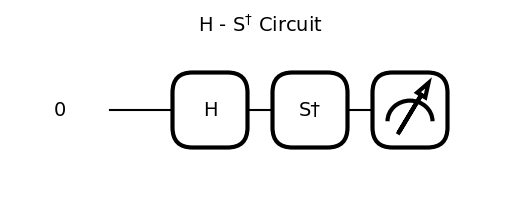

In [14]:
import pennylane as qp
import pandas as pd
import matplotlib.pyplot as plt

dev = qp.device("default.qubit", wires=1)

@qp.set_shots(shots=10000)
@qp.qnode(dev)
def circuit_sdg():
    qp.Hadamard(wires=0)
    # sdg-gate
    qp.adjoint(qp.S(wires=0))
    return qp.counts(wires=[0])

counts = circuit_sdg()

df = pd.DataFrame(list(counts.items()), columns=['State', 'Count'])
df['Probability'] = df['Count'] / df['Count'].sum()
print('H-Sdg circuit results:')
print(df.to_string(index=False))

print(qp.draw(circuit_sdg)())

fig, ax = qp.drawer.draw_mpl(circuit_sdg)()
fig.suptitle('H - S$^{\\dagger}$ Circuit', fontsize=14)
plt.show()

H-Tdg circuit results:
State  Count  Probability
    0   4961       0.4961
    1   5039       0.5039
0: ──H──T†─┤  Counts


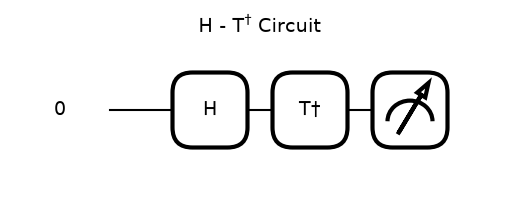

In [1]:
import pennylane as qp
import pandas as pd
import matplotlib.pyplot as plt

dev = qp.device("default.qubit", wires=1)

@qp.set_shots(shots=10000)
@qp.qnode(dev)
def circuit_tdg():
    qp.Hadamard(wires=0)
    # tdg-gate
    qp.adjoint(qp.T(wires=0))
    return qp.counts(wires=[0])

counts = circuit_tdg()

df = pd.DataFrame(list(counts.items()), columns=['State', 'Count'])
df['Probability'] = df['Count'] / df['Count'].sum()
print('H-Tdg circuit results:')
print(df.to_string(index=False))

print(qp.draw(circuit_tdg)())

fig, ax = qp.drawer.draw_mpl(circuit_tdg)()
fig.suptitle('H - T$^{\\dagger}$ Circuit', fontsize=14)
plt.show()

<a id="task4"></a>
<h3> Task 4 </h3>

For each one of the discussed 4 phase gates construct the following circuit:

<ul>
    <li>Create a circuit with one qubit,</li>
    <li>apply Hadamard operator,</li>
    <li>apply the corresponding phase operator,</li>
    <li>apply Hadamard operator,</li>
    <li>make a measurement.</li>
</ul>

Guess the measurement outcome in each case before executing the code.

<h3> Solution </h3>

H-S-H circuit results:
State  Count  Probability
    0   4992       0.4992
    1   5008       0.5008
0: ──H──S──H─┤  Counts


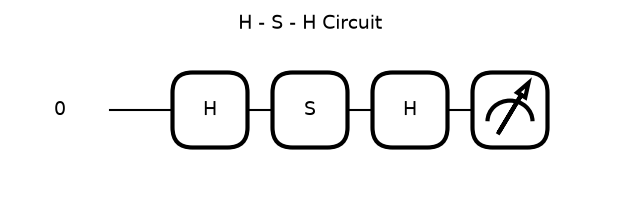

In [2]:
import pennylane as qp
import pandas as pd
import matplotlib.pyplot as plt

dev = qp.device("default.qubit", wires=1)

@qp.set_shots(shots=10000)
@qp.qnode(dev)
def circuit_s():
    qp.Hadamard(wires=0)
    # s-gate
    qp.S(wires=0)
    qp.Hadamard(wires=0)
    return qp.counts(wires=[0])

counts = circuit_s()

df = pd.DataFrame(list(counts.items()), columns=['State', 'Count'])
df['Probability'] = df['Count'] / df['Count'].sum()
print('H-S-H circuit results:')
print(df.to_string(index=False))

print(qp.draw(circuit_s)())

fig, ax = qp.drawer.draw_mpl(circuit_s)()
fig.suptitle('H - S - H Circuit', fontsize=14)
plt.show()

H-T-H circuit results:
State  Count  Probability
    0   8592       0.8592
    1   1408       0.1408
0: ──H──T──H─┤  Counts


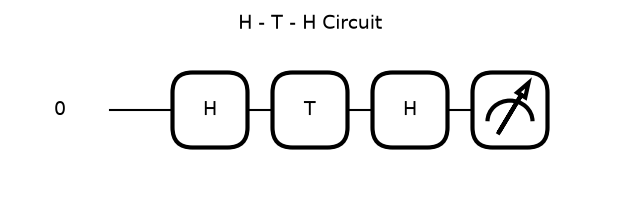

In [3]:
import pennylane as qp
import pandas as pd
import matplotlib.pyplot as plt

dev = qp.device("default.qubit", wires=1)

@qp.set_shots(shots=10000)
@qp.qnode(dev)
def circuit_t():
    qp.Hadamard(wires=0)
    # t-gate
    qp.T(wires=0)
    qp.Hadamard(wires=0)
    return qp.counts(wires=[0])

counts = circuit_t()

df = pd.DataFrame(list(counts.items()), columns=['State', 'Count'])
df['Probability'] = df['Count'] / df['Count'].sum()
print('H-T-H circuit results:')
print(df.to_string(index=False))

print(qp.draw(circuit_t)())

fig, ax = qp.drawer.draw_mpl(circuit_t)()
fig.suptitle('H - T - H Circuit', fontsize=14)
plt.show()

H-Sdg-H circuit results:
State  Count  Probability
    0   4961       0.4961
    1   5039       0.5039
0: ──H──S†──H─┤  Counts


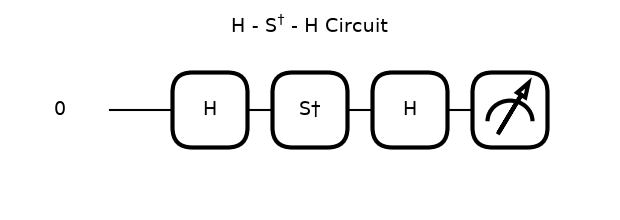

In [4]:
import pennylane as qp
import pandas as pd
import matplotlib.pyplot as plt

dev = qp.device("default.qubit", wires=1)

@qp.set_shots(shots=10000)
@qp.qnode(dev)
def circuit_sdg():
    qp.Hadamard(wires=0)
    # sdg-gate
    qp.adjoint(qp.S(wires=0))
    qp.Hadamard(wires=0)
    return qp.counts(wires=[0])

counts = circuit_sdg()

df = pd.DataFrame(list(counts.items()), columns=['State', 'Count'])
df['Probability'] = df['Count'] / df['Count'].sum()
print('H-Sdg-H circuit results:')
print(df.to_string(index=False))

print(qp.draw(circuit_sdg)())

fig, ax = qp.drawer.draw_mpl(circuit_sdg)()
fig.suptitle('H - S$^{\\dagger}$ - H Circuit', fontsize=14)
plt.show()

H-Tdg-H circuit results:
State  Count  Probability
    0   8526       0.8526
    1   1474       0.1474
0: ──H──T†──H─┤  Counts


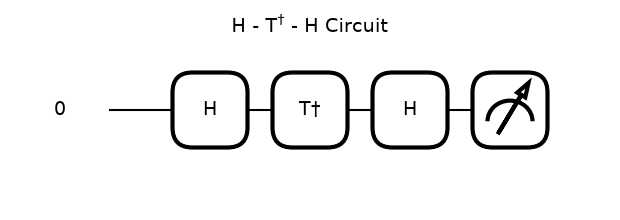

In [5]:
import pennylane as qp
import pandas as pd
import matplotlib.pyplot as plt

dev = qp.device("default.qubit", wires=1)

@qp.set_shots(shots=10000)
@qp.qnode(dev)
def circuit_tdg():
    qp.Hadamard(wires=0)
    # tdg-gate
    qp.adjoint(qp.T(wires=0))
    qp.Hadamard(wires=0)
    return qp.counts(wires=[0])

counts = circuit_tdg()

df = pd.DataFrame(list(counts.items()), columns=['State', 'Count'])
df['Probability'] = df['Count'] / df['Count'].sum()
print('H-Tdg-H circuit results:')
print(df.to_string(index=False))

print(qp.draw(circuit_tdg)())

fig, ax = qp.drawer.draw_mpl(circuit_tdg)()
fig.suptitle('H - T$^{\\dagger}$ - H Circuit', fontsize=14)
plt.show()


<a id="task5"></a>
<h3> Task 5 </h3>

Repeat previous experiment for different number of $\qgate{H}$-gates and $\qgate{T}$-gates, but this time applying them in opposite order: first $\qgate{H}$ and then $\qgate{T}$.

<h3> Solution </h3>

 Iterations  P(|0>)  P(|1>)
          1  0.5036  0.4964
          2  0.8520  0.1480
          3  0.7420  0.2580
          4  0.5762  0.4238
          5  0.9792  0.0208
          6  0.4737  0.5263
          7  0.9378  0.0622
          8  0.6376  0.3624
          9  0.6621  0.3379
         10  0.9180  0.0820
         11  0.4720  0.5280
         12  0.9885  0.0115
         13  0.5522  0.4478
         14  0.7783  0.2217
         15  0.8334  0.1666
         16  0.5213  0.4787
         17  0.9988  0.0012
         18  0.4864  0.5136
         19  0.8728  0.1272
         20  0.7135  0.2865
         21  0.5946  0.4054
         22  0.9661  0.0339
         23  0.4556  0.5444
         24  0.9556  0.0444


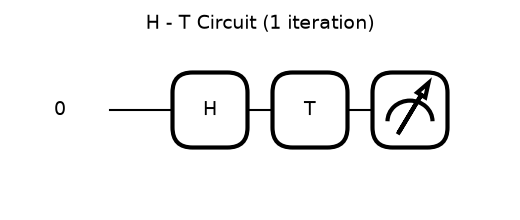

In [6]:
import pennylane as qp
import pandas as pd
import matplotlib.pyplot as plt

results = []
for i in range(1, 25):
    dev = qp.device("default.qubit", wires=1)

    @qp.set_shots(shots=10000)
    @qp.qnode(dev)
    def circuit():
        for j in range(i):
            qp.Hadamard(wires=0)
            qp.T(wires=0)
        return qp.counts(wires=[0])

    counts = circuit()
    p0 = counts.get('0', 0) / 10000
    p1 = counts.get('1', 0) / 10000
    results.append({'Iterations': i, 'P(|0>)': round(p0, 4), 'P(|1>)': round(p1, 4)})

df = pd.DataFrame(results)
print(df.to_string(index=False))

# Show circuit for 1 iteration
dev_vis = qp.device("default.qubit", wires=1)

@qp.qnode(dev_vis)
def circuit_vis():
    qp.Hadamard(wires=0)
    qp.T(wires=0)
    return qp.state()

fig, ax = qp.drawer.draw_mpl(circuit_vis)()
fig.suptitle('H - T Circuit (1 iteration)', fontsize=14)
plt.show()

<a id="task6"></a>
<h3> Task 6 (discussion) </h3>

Why do the outcomes repeat after several iterations?

<h3> Solution </h3>

We have $(\qgate{HTH})^n$ for some $n$. As a result we have $\qgate{H T HH T HH T} \cdots \qgate{HH T H}$, and $\qgate{HH} = \qgate{I}$, so in result $(\qgate{HTH})^n = \qgate{HT}^n\qgate{H}$. Because $\qgate{T}^8 = \qgate{I}$, after 8 iterations outcomes repeat.